<a href="https://colab.research.google.com/github/11465005-tech/ceva/blob/main/chinese_pipelined_bert_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 中文版 VA 情感強度預測 v5 — BERT 多任務學習版

**核心改動：拋棄容易退化的 NNword 加權求和架構，改用 BERT 多任務學習**

| 版本 | 架構 |
|------|------|
| v1~v4 | NNword（相似度加權）→ NNmod（修飾詞移位）|
| **v5** | **共享 BERT encoder + Word VA 頭 + Phrase VA 頭，同時訓練（多任務學習）** |

**設計理念：**
- 用同一個 BERT 對單詞和片語做 encode
- Word 任務和 Phrase 任務共享 BERT 參數，梯度同時更新
- Word 訓練學到的情感語意表徵，直接遷移強化 Phrase 的判斷
- 不再有「相似度加權退化成常數輸出」的問題，因為 BERT 對每個輸入文字都會產生獨特的語意向量

**資料集：** CVAW（單詞）+ CVAP（短語），訓練:測試 = 8:2
**評估指標：** MAE、MSE、Pearson r（Chinese EmoBank 論文）+ Kendall τ、Spearman ρ（Pipelined NN 論文）

## 0. 安裝套件

In [1]:
!pip install transformers torch numpy pandas scikit-learn matplotlib scipy -q

## 1. 掛載 Google Drive 並載入資料集

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import kendalltau, spearmanr, pearsonr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

# ---- 路徑設定（依實際路徑修改）----
CVAW_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAW_SD/CVAW_all_SD.csv'
CVAP_PATH = '/content/drive/MyDrive/研究/dimABSA/DataSets/ChineseEmoBank/CVAP_SD/CVAP_all_SD.csv'

cvaw = pd.read_csv(CVAW_PATH, sep='\t')
cvap = pd.read_csv(CVAP_PATH, sep='\t')
print(f'CVAW 筆數: {len(cvaw)}  CVAP 筆數: {len(cvap)}')

使用裝置: cuda
CVAW 筆數: 5512  CVAP 筆數: 2250


## 2. 資料前處理

In [4]:
def normalize_va(df, val_col='Valence_Mean', aro_col='Arousal_Mean'):
    """VA 分數 [1,9] → [0,1]"""
    df = df.copy()
    df['valence'] = (df[val_col] - 1) / 8.0
    df['arousal'] = (df[aro_col] - 1) / 8.0
    return df

cvaw = normalize_va(cvaw)
cvap = normalize_va(cvap)

# CVAP 短語切割：修飾詞 + 核心詞（核心詞需在 CVAW 中），僅作分析用途
cvaw_word_set = set(cvaw['Word'].tolist())

def split_phrase(phrase, cvaw_words):
    for mod_len in [1, 2, 3, 4]:
        if len(phrase) > mod_len:
            mod  = phrase[:mod_len]
            core = phrase[mod_len:]
            if core in cvaw_words:
                return mod, core
    return None, None

mods, cores = [], []
for phrase in cvap['Phrase']:
    m, c = split_phrase(phrase, cvaw_word_set)
    mods.append(m); cores.append(c)

cvap['modifier']  = mods
cvap['core_word'] = cores

# 8:2 切分
cvaw_train, cvaw_test = train_test_split(cvaw, test_size=0.2, random_state=42)
cvap_train, cvap_test = train_test_split(cvap, test_size=0.2, random_state=42)
print(f'CVAW 訓練:{len(cvaw_train)}  測試:{len(cvaw_test)}')
print(f'CVAP 訓練:{len(cvap_train)}  測試:{len(cvap_test)}')

CVAW 訓練:4409  測試:1103
CVAP 訓練:1800  測試:450


## 3. 載入中文 BERT

In [5]:
from transformers import AutoTokenizer, AutoModel

BERT_NAME = 'hfl/chinese-bert-wwm-ext'  # 繁簡通用，對中文情感任務效果穩定

print('下載 BERT（約需 1~2 分鐘）...')
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert = AutoModel.from_pretrained(BERT_NAME).to(device)
BERT_DIM = bert.config.hidden_size
print(f'✅ 載入完成 | hidden size: {BERT_DIM}')

下載 BERT（約需 1~2 分鐘）...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hfl/chinese-bert-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 載入完成 | hidden size: 768


## 4. 模型定義：共享 BERT + 雙任務頭（Multi-task Learning）

In [6]:
class MultiTaskVA(nn.Module):
    """
    共享 BERT encoder，接兩個任務頭：
    - word_head：預測單詞的 Valence / Arousal
    - phrase_head：預測片語的 Valence / Arousal
    兩個頭共用同一個 BERT，梯度同時反傳，
    讓 word 任務學到的情感表徵直接增強 phrase 任務。
    """
    def __init__(self, bert, bert_dim, dropout=0.1):
        super().__init__()
        self.bert = bert
        self.dropout = nn.Dropout(dropout)

        # word 任務頭
        self.word_head = nn.Sequential(
            nn.Linear(bert_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)   # [valence, arousal]
        )
        # phrase 任務頭
        self.phrase_head = nn.Sequential(
            nn.Linear(bert_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def encode(self, input_ids, attention_mask):
        """用 [CLS] token 的輸出當作整句/整詞的表徵"""
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [CLS]
        return self.dropout(cls)

    def forward_word(self, input_ids, attention_mask):
        cls = self.encode(input_ids, attention_mask)
        out = torch.sigmoid(self.word_head(cls))
        return out[:, 0:1], out[:, 1:2]   # valence, arousal

    def forward_phrase(self, input_ids, attention_mask):
        cls = self.encode(input_ids, attention_mask)
        out = torch.sigmoid(self.phrase_head(cls))
        return out[:, 0:1], out[:, 1:2]

model = MultiTaskVA(bert, BERT_DIM).to(device)
print('模型建立完成')
print(f'總參數量: {sum(p.numel() for p in model.parameters()):,}')

模型建立完成
總參數量: 102,465,028


## 5. 資料編碼：把文字轉成 BERT 的 input_ids

In [7]:
MAX_LEN = 16   # 單詞/短語都很短，16 已足夠

def encode_texts(texts):
    """批次把文字編碼成 BERT 輸入格式"""
    enc = tokenizer(
        list(texts), padding=True, truncation=True,
        max_length=MAX_LEN, return_tensors='pt'
    )
    return enc['input_ids'].to(device), enc['attention_mask'].to(device)

# 編碼 CVAW 訓練/測試資料
word_train_ids, word_train_mask = encode_texts(cvaw_train['Word'].tolist())
word_train_val = torch.tensor(cvaw_train['valence'].values, dtype=torch.float32).unsqueeze(1).to(device)
word_train_aro = torch.tensor(cvaw_train['arousal'].values, dtype=torch.float32).unsqueeze(1).to(device)

word_test_ids, word_test_mask = encode_texts(cvaw_test['Word'].tolist())
word_test_val = cvaw_test['valence'].values
word_test_aro = cvaw_test['arousal'].values

# 編碼 CVAP 訓練/測試資料
phrase_train_ids, phrase_train_mask = encode_texts(cvap_train['Phrase'].tolist())
phrase_train_val = torch.tensor(cvap_train['valence'].values, dtype=torch.float32).unsqueeze(1).to(device)
phrase_train_aro = torch.tensor(cvap_train['arousal'].values, dtype=torch.float32).unsqueeze(1).to(device)

phrase_test_ids, phrase_test_mask = encode_texts(cvap_test['Phrase'].tolist())
phrase_test_val = cvap_test['valence'].values
phrase_test_aro = cvap_test['arousal'].values

print(f'Word  訓練: {word_train_ids.shape}   測試: {word_test_ids.shape}')
print(f'Phrase訓練: {phrase_train_ids.shape} 測試: {phrase_test_ids.shape}')

Word  訓練: torch.Size([4409, 9])   測試: torch.Size([1103, 10])
Phrase訓練: torch.Size([1800, 8]) 測試: torch.Size([450, 9])


## 6. 多任務聯合訓練（Word + Phrase 同時訓練，共享 BERT）
**核心：** 每個 epoch 同時計算 word loss 和 phrase loss，
加總後一起 backward，讓 BERT 底層參數同時被兩個任務的梯度更新。
這就是「word 訓練成果加強 phrase 訓練」的具體實作方式。

In [8]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

word_dataset = TensorDataset(word_train_ids, word_train_mask, word_train_val, word_train_aro)
word_loader  = DataLoader(word_dataset, batch_size=BATCH_SIZE, shuffle=True)

phrase_dataset = TensorDataset(phrase_train_ids, phrase_train_mask, phrase_train_val, phrase_train_aro)
phrase_loader  = DataLoader(phrase_dataset, batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# word loss 權重可以略低於 phrase（phrase 是主任務），這裡先用 1:1
WORD_LOSS_WEIGHT   = 1.0
PHRASE_LOSS_WEIGHT = 1.0

N_EPOCHS = 6   # BERT fine-tune 通常 3~10 epoch 就足夠，過多容易過擬合

print('=== 多任務聯合訓練（Word + Phrase 共享 BERT）===')
history = {'word_loss': [], 'phrase_loss': [], 'total_loss': []}

for epoch in range(N_EPOCHS):
    model.train()
    epoch_word_loss, epoch_phrase_loss, n_batches = 0.0, 0.0, 0

    word_iter   = iter(word_loader)
    phrase_iter = iter(phrase_loader)
    n_steps = max(len(word_loader), len(phrase_loader))

    for step in range(n_steps):
        # 兩個 loader 長度不同時循環取用
        try:
            w_ids, w_mask, w_val, w_aro = next(word_iter)
        except StopIteration:
            word_iter = iter(word_loader)
            w_ids, w_mask, w_val, w_aro = next(word_iter)
        try:
            p_ids, p_mask, p_val, p_aro = next(phrase_iter)
        except StopIteration:
            phrase_iter = iter(phrase_loader)
            p_ids, p_mask, p_val, p_aro = next(phrase_iter)

        # ── Word 任務 forward ──
        pred_wv, pred_wa = model.forward_word(w_ids, w_mask)
        word_loss = 0.5 * ((pred_wv - w_val)**2 + (pred_wa - w_aro)**2).mean()

        # ── Phrase 任務 forward（共用同一個 BERT，這一步會更新 BERT 底層權重）──
        pred_pv, pred_pa = model.forward_phrase(p_ids, p_mask)
        phrase_loss = 0.5 * ((pred_pv - p_val)**2 + (pred_pa - p_aro)**2).mean()

        # ── 合併 loss，一起 backward（核心：word 梯度和 phrase 梯度同時更新 BERT）──
        total_loss = WORD_LOSS_WEIGHT * word_loss + PHRASE_LOSS_WEIGHT * phrase_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_word_loss   += word_loss.item()
        epoch_phrase_loss += phrase_loss.item()
        n_batches += 1

    avg_word_loss   = epoch_word_loss / n_batches
    avg_phrase_loss = epoch_phrase_loss / n_batches
    avg_total       = avg_word_loss + avg_phrase_loss

    history['word_loss'].append(avg_word_loss)
    history['phrase_loss'].append(avg_phrase_loss)
    history['total_loss'].append(avg_total)

    print(f'Epoch {epoch+1}/{N_EPOCHS} | Word Loss: {avg_word_loss:.4f} | '
          f'Phrase Loss: {avg_phrase_loss:.4f} | Total: {avg_total:.4f}')

print('訓練完成')

=== 多任務聯合訓練（Word + Phrase 共享 BERT）===
Epoch 1/6 | Word Loss: 0.0187 | Phrase Loss: 0.0110 | Total: 0.0297
Epoch 2/6 | Word Loss: 0.0110 | Phrase Loss: 0.0037 | Total: 0.0146
Epoch 3/6 | Word Loss: 0.0082 | Phrase Loss: 0.0028 | Total: 0.0109
Epoch 4/6 | Word Loss: 0.0066 | Phrase Loss: 0.0022 | Total: 0.0088
Epoch 5/6 | Word Loss: 0.0052 | Phrase Loss: 0.0019 | Total: 0.0071
Epoch 6/6 | Word Loss: 0.0043 | Phrase Loss: 0.0018 | Total: 0.0061
訓練完成


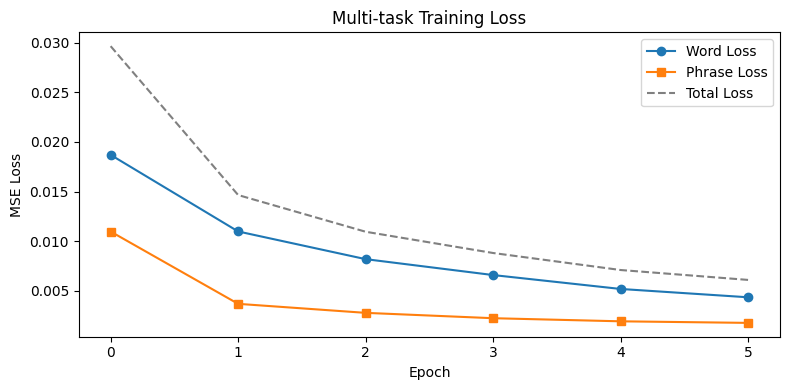

In [9]:
plt.figure(figsize=(8,4))
plt.plot(history['word_loss'],   label='Word Loss',   marker='o')
plt.plot(history['phrase_loss'], label='Phrase Loss', marker='s')
plt.plot(history['total_loss'],  label='Total Loss',  linestyle='--', color='gray')
plt.title('Multi-task Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout(); plt.show()

## 7. 預測函式

In [10]:
@torch.no_grad()
def predict_word_va(text):
    """用 word_head 預測單詞 VA"""
    model.eval()
    ids, mask = encode_texts([text])
    v, a = model.forward_word(ids, mask)
    return v.item(), a.item()

@torch.no_grad()
def predict_phrase_va(text):
    """用 phrase_head 預測片語 VA（text 是完整片語字串，例如「非常開心」）"""
    model.eval()
    ids, mask = encode_texts([text])
    v, a = model.forward_phrase(ids, mask)
    return v.item(), a.item()

def va_label(v, a):
    pol = '正向' if v>=0.625 else ('負向' if v<=0.375 else '中性')
    act = '高喚起' if a>=0.625 else ('低喚起' if a<=0.375 else '中喚起')
    return f'{pol}/{act}'

# 測試
print('=== 單詞預測（word_head）===')
for w in ['開心','難過','憤怒','平靜','興奮','恐懼']:
    v, a = predict_word_va(w)
    print(f'「{w}」V={v:.4f} A={a:.4f} → {va_label(v,a)}')

print()
print('=== 片語預測（phrase_head，BERT 直接 encode 完整片語）===')
for phrase in ['非常開心','沒有希望','完全不滿意','極為不安','相當平靜','可能失望']:
    v, a = predict_phrase_va(phrase)
    print(f'「{phrase}」V={v:.4f} A={a:.4f} → {va_label(v,a)}')

=== 單詞預測（word_head）===
「開心」V=0.7958 A=0.6964 → 正向/高喚起
「難過」V=0.2397 A=0.5325 → 負向/中喚起
「憤怒」V=0.1548 A=0.8661 → 負向/高喚起
「平靜」V=0.6465 A=0.1471 → 正向/低喚起
「興奮」V=0.7975 A=0.7834 → 正向/高喚起
「恐懼」V=0.2253 A=0.7103 → 負向/高喚起

=== 片語預測（phrase_head，BERT 直接 encode 完整片語）===
「非常開心」V=0.9128 A=0.8266 → 正向/高喚起
「沒有希望」V=0.2102 A=0.5364 → 負向/中喚起
「完全不滿意」V=0.1475 A=0.7451 → 負向/高喚起
「極為不安」V=0.1249 A=0.7880 → 負向/高喚起
「相當平靜」V=0.7540 A=0.1853 → 正向/低喚起
「可能失望」V=0.2777 A=0.5734 → 負向/中喚起


## 8. 評估函式

In [11]:
def compute_metrics(preds, golds, label):
    p = np.array(preds); g = np.array(golds)
    mae    = np.mean(np.abs(p - g))
    mse    = np.mean((p - g) ** 2)
    r, _   = pearsonr(p, g)
    tau, _ = kendalltau(p, g)
    rho, _ = spearmanr(p, g)
    print(f'  {label:30s} | MAE={mae:.4f}  MSE={mse:.4f}  r={r:.4f}  τ={tau:.4f}  ρ={rho:.4f}')
    return mae, mse, r, tau, rho

@torch.no_grad()
def batch_predict_word(ids, mask, batch_size=64):
    model.eval()
    all_v, all_a = [], []
    for i in range(0, len(ids), batch_size):
        v, a = model.forward_word(ids[i:i+batch_size], mask[i:i+batch_size])
        all_v.append(v.cpu().numpy()); all_a.append(a.cpu().numpy())
    return np.concatenate(all_v).flatten(), np.concatenate(all_a).flatten()

@torch.no_grad()
def batch_predict_phrase(ids, mask, batch_size=64):
    model.eval()
    all_v, all_a = [], []
    for i in range(0, len(ids), batch_size):
        v, a = model.forward_phrase(ids[i:i+batch_size], mask[i:i+batch_size])
        all_v.append(v.cpu().numpy()); all_a.append(a.cpu().numpy())
    return np.concatenate(all_v).flatten(), np.concatenate(all_a).flatten()

## 9. 訓練集評估

In [12]:
print('='*75)
print('【訓練集評估】')
print('='*75)

pv_trw, pa_trw = batch_predict_word(word_train_ids, word_train_mask)
gv_trw = cvaw_train['valence'].values
ga_trw = cvaw_train['arousal'].values
print('\n[Word head] CVAW 訓練集')
compute_metrics(pv_trw, gv_trw, 'Valence')
compute_metrics(pa_trw, ga_trw, 'Arousal')

pv_trm, pa_trm = batch_predict_phrase(phrase_train_ids, phrase_train_mask)
gv_trm = cvap_train['valence'].values
ga_trm = cvap_train['arousal'].values
print('\n[Phrase head] CVAP 訓練集')
compute_metrics(pv_trm, gv_trm, 'Valence')
compute_metrics(pa_trm, ga_trm, 'Arousal')

【訓練集評估】

[Word head] CVAW 訓練集
  Valence                        | MAE=0.0348  MSE=0.0020  r=0.9774  τ=0.8640  ρ=0.9703
  Arousal                        | MAE=0.0402  MSE=0.0027  r=0.9578  τ=0.8389  ρ=0.9617

[Phrase head] CVAP 訓練集
  Valence                        | MAE=0.0256  MSE=0.0011  r=0.9912  τ=0.9203  ρ=0.9911
  Arousal                        | MAE=0.0255  MSE=0.0011  r=0.9764  τ=0.8673  ρ=0.9756


(np.float64(0.02547960927426815),
 np.float64(0.001066395261353315),
 np.float64(0.9764390789646042),
 np.float64(0.867313795454079),
 np.float64(0.9756057908213438))

## 10. 測試集評估

In [13]:
print('='*75)
print('【測試集評估】')
print('='*75)

pv_tew, pa_tew = batch_predict_word(word_test_ids, word_test_mask)
print('\n[Word head] CVAW 測試集')
compute_metrics(pv_tew, word_test_val, 'Valence')
compute_metrics(pa_tew, word_test_aro, 'Arousal')

pv_tem, pa_tem = batch_predict_phrase(phrase_test_ids, phrase_test_mask)
print('\n[Phrase head] CVAP 測試集')
compute_metrics(pv_tem, phrase_test_val, 'Valence')
compute_metrics(pa_tem, phrase_test_aro, 'Arousal')

【測試集評估】

[Word head] CVAW 測試集
  Valence                        | MAE=0.0614  MSE=0.0075  r=0.9097  τ=0.7182  ρ=0.8817
  Arousal                        | MAE=0.0992  MSE=0.0162  r=0.7134  τ=0.5174  ρ=0.6955

[Phrase head] CVAP 測試集
  Valence                        | MAE=0.0401  MSE=0.0028  r=0.9731  τ=0.8648  ρ=0.9738
  Arousal                        | MAE=0.0432  MSE=0.0032  r=0.9314  τ=0.7573  ρ=0.9167


(np.float64(0.04321508776081934),
 np.float64(0.0031562640203750872),
 np.float64(0.9314311335315647),
 np.float64(0.7573182968602805),
 np.float64(0.916680844449616))

## 11. 結果摘要表 + 視覺化

In [14]:
def metrics(p, g):
    pa = np.array(p); ga = np.array(g)
    mae    = np.mean(np.abs(pa - ga))
    mse    = np.mean((pa - ga)**2)
    r, _   = pearsonr(pa, ga)
    tau, _ = kendalltau(pa, ga)
    rho, _ = spearmanr(pa, ga)
    return round(mae,4), round(mse,4), round(r,4), round(tau,4), round(rho,4)

rows = [
    ('Word',   '訓練', 'Valence', *metrics(pv_trw, gv_trw)),
    ('Word',   '訓練', 'Arousal', *metrics(pa_trw, ga_trw)),
    ('Word',   '測試', 'Valence', *metrics(pv_tew, word_test_val)),
    ('Word',   '測試', 'Arousal', *metrics(pa_tew, word_test_aro)),
    ('Phrase', '訓練', 'Valence', *metrics(pv_trm, gv_trm)),
    ('Phrase', '訓練', 'Arousal', *metrics(pa_trm, ga_trm)),
    ('Phrase', '測試', 'Valence', *metrics(pv_tem, phrase_test_val)),
    ('Phrase', '測試', 'Arousal', *metrics(pa_tem, phrase_test_aro)),
]
summary = pd.DataFrame(rows,
    columns=['任務','資料集','維度','MAE','MSE','Pearson r','Kendall τ','Spearman ρ'])
print(summary.to_string(index=False))

    任務 資料集      維度    MAE    MSE  Pearson r  Kendall τ  Spearman ρ
  Word  訓練 Valence 0.0348 0.0020     0.9774     0.8640      0.9703
  Word  訓練 Arousal 0.0402 0.0027     0.9578     0.8389      0.9617
  Word  測試 Valence 0.0614 0.0075     0.9097     0.7182      0.8817
  Word  測試 Arousal 0.0992 0.0162     0.7134     0.5174      0.6955
Phrase  訓練 Valence 0.0256 0.0011     0.9912     0.9203      0.9911
Phrase  訓練 Arousal 0.0255 0.0011     0.9764     0.8673      0.9756
Phrase  測試 Valence 0.0401 0.0028     0.9731     0.8648      0.9738
Phrase  測試 Arousal 0.0432 0.0032     0.9314     0.7573      0.9167


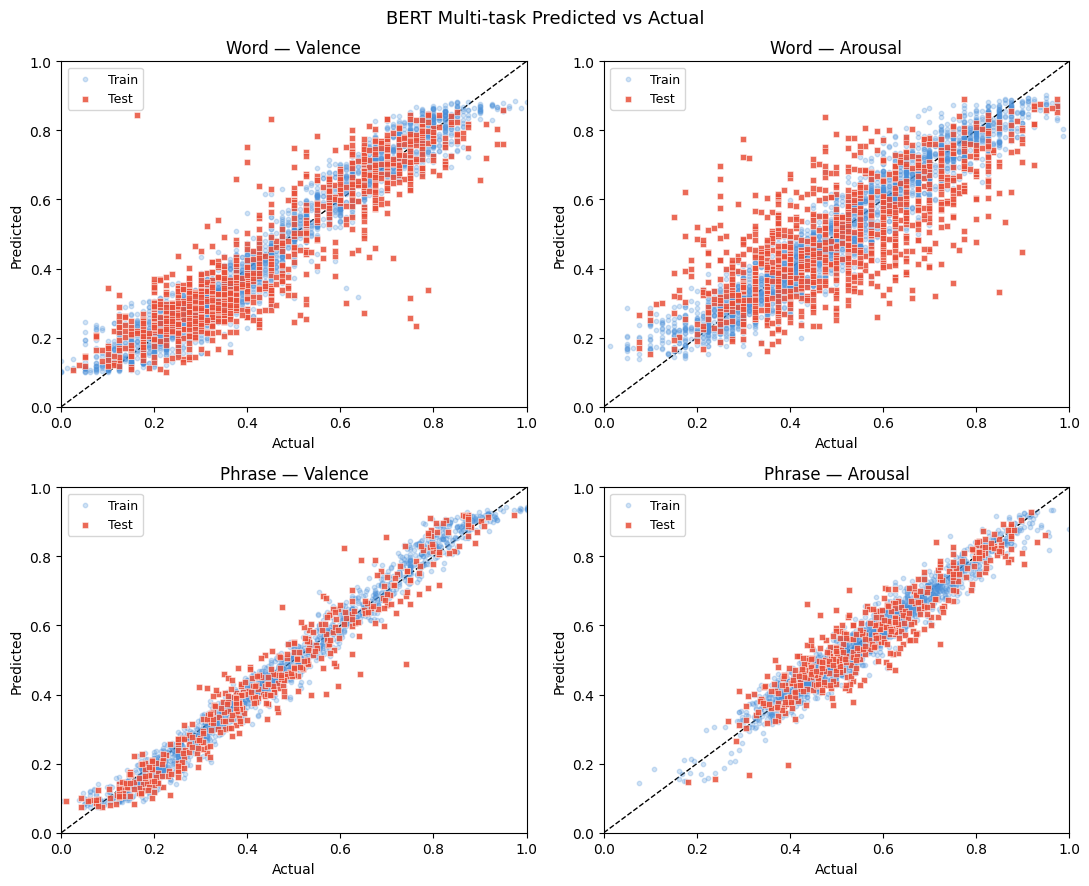

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle('BERT Multi-task Predicted vs Actual', fontsize=13)

configs = [
    (axes[0,0], pv_trw, gv_trw, pv_tew, word_test_val, 'Word — Valence',   '#4A90D9', '#E8503A'),
    (axes[0,1], pa_trw, ga_trw, pa_tew, word_test_aro, 'Word — Arousal',   '#4A90D9', '#E8503A'),
    (axes[1,0], pv_trm, gv_trm, pv_tem, phrase_test_val, 'Phrase — Valence', '#4A90D9', '#E8503A'),
    (axes[1,1], pa_trm, ga_trm, pa_tem, phrase_test_aro, 'Phrase — Arousal', '#4A90D9', '#E8503A'),
]

for ax, ptr, gtr, pte, gte, title, c_train, c_test in configs:
    ax.scatter(gtr, ptr, alpha=0.25, s=10, color=c_train, label='Train', zorder=2)
    ax.scatter(gte, pte, alpha=0.85, s=20, color=c_test, marker='s',
               edgecolors='white', linewidths=0.4, label='Test', zorder=3)
    ax.plot([0,1],[0,1],'k--', linewidth=1, zorder=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

## 12. 互動預測

In [16]:
# 修改這裡進行自訂預測
TEST_WORD   = '害怕'
TEST_PHRASE = '非常害怕'

v, a = predict_word_va(TEST_WORD)
print(f'單詞「{TEST_WORD}」 → V={v:.4f} A={a:.4f}  {va_label(v,a)}')

v, a = predict_phrase_va(TEST_PHRASE)
print(f'片語「{TEST_PHRASE}」 → V={v:.4f} A={a:.4f}  {va_label(v,a)}')

單詞「害怕」 → V=0.2512 A=0.6459  負向/高喚起
片語「非常害怕」 → V=0.1168 A=0.8077  負向/高喚起


## 13. 消融測試：驗證 word 任務是否真的有幫助 phrase
比較「只訓練 phrase_head（單任務）」vs「word+phrase 聯合訓練（多任務）」，
驗證多任務學習確實能用 word 增強 phrase 的判斷力。

In [17]:
print('=== 消融測試：單任務（只用 phrase）vs 多任務（word+phrase）===')
print(f'多任務模型 Phrase 測試集表現：')
compute_metrics(pv_tem, phrase_test_val, 'Valence (multi-task)')
compute_metrics(pa_tem, phrase_test_aro, 'Arousal (multi-task)')
print()
print('若要比較單任務基準，可重新建立一個只用 phrase_loss 訓練的模型，')
print('訓練步驟相同但拿掉 word_loss 項，比較兩者在 CVAP 測試集上的 τ 和 ρ。')
print('預期：多任務版本的 τ/ρ 應高於單任務版本，證明 word 訓練確實增強了 phrase 判斷。')

=== 消融測試：單任務（只用 phrase）vs 多任務（word+phrase）===
多任務模型 Phrase 測試集表現：
  Valence (multi-task)           | MAE=0.0401  MSE=0.0028  r=0.9731  τ=0.8648  ρ=0.9738
  Arousal (multi-task)           | MAE=0.0432  MSE=0.0032  r=0.9314  τ=0.7573  ρ=0.9167

若要比較單任務基準，可重新建立一個只用 phrase_loss 訓練的模型，
訓練步驟相同但拿掉 word_loss 項，比較兩者在 CVAP 測試集上的 τ 和 ρ。
預期：多任務版本的 τ/ρ 應高於單任務版本，證明 word 訓練確實增強了 phrase 判斷。
